## Team STAR Part 1: Get comfortable using Tsim
![surface_code.png](./assets/surface_code.png)

Familiarize yourself with the surface code and its stabilizer structure. 
Use Tsim to construct a distance-3 surface code and simulate two rounds of syndrome extraction.

Start by identifying the data and ancilla qubits, the stabilizer checks being measured, and how syndrome information is extracted over time. 
Use this part to get comfortable building the code in Tsim, running repeated syndrome cycles, and understanding how errors affect the circuit.

**Goal:** Build intuition for the distance-3 surface code, repeated syndrome extraction, and the simulation workflow in Tsim.


In [94]:
# Using Squin
from typing import Any

from bloqade import squin, tsim
from bloqade.pyqrack import StackMemorySimulator
from bloqade.types import MeasurementResult, Qubit
from kirin.dialects.ilist import IList
# import tsim

# this will help us have return types for our methods that have more intuitive names
Register = IList[Qubit, Any]
Measurement = IList[MeasurementResult, Any]

# this function will help us visualize some circuits
def show_circuit(squin_kernel, h=400):
    @squin.kernel
    def _to_visualize():
        _ = squin_kernel()

    return tsim.Circuit(_to_visualize).diagram(height=h)


@squin.kernel
def bell_state() -> Measurement:
    qubits = squin.qalloc(2)
    squin.h(qubits[0])
    squin.cx(qubits[0], qubits[1])
    bits = squin.broadcast.measure(qubits)
    return bits

show_circuit(bell_state)

def build_stabilizer_supports(n):
    """
    Costruisce i supporti degli stabilizzatori per una rotated surface code n x n.

    Ritorna:
        z_supports: tuple di tuple
        x_supports: tuple di tuple

    Convenzione data qubit:
        0   1   2
        3   4   5
        6   7   8
    """

    if n < 3:
        raise ValueError("n deve essere almeno 3")

    if n % 2 == 0:
        raise ValueError("n deve essere dispari: 3, 5, 7, ...")

    expected = (n**2 - 1) // 2

    def q(row, col):
        return row * n + col

    z_supports = []
    x_supports = []

    # =========================
    # Z STABILIZERS
    # =========================

    # Bordo alto: coppie orizzontali
    for col in range(0, n - 1, 2):
        z_supports.append((
            q(0, col),
            q(0, col + 1),
        ))

    # Interni Z: plaquette 2x2 con parità dispari
    for row in range(n - 1):
        for col in range(n - 1):
            if (row + col) % 2 == 1:
                z_supports.append((
                    q(row, col),
                    q(row, col + 1),
                    q(row + 1, col),
                    q(row + 1, col + 1),
                ))

    # Bordo basso: coppie orizzontali sfalsate
    for col in range(1, n - 1, 2):
        z_supports.append((
            q(n - 1, col),
            q(n - 1, col + 1),
        ))

    # =========================
    # X STABILIZERS
    # =========================

    for row in range(n - 1):

        # Bordo sinistro: coppie verticali sfalsate
        if row % 2 == 1:
            x_supports.append((
                q(row, 0),
                q(row + 1, 0),
            ))

        # Interni X: plaquette 2x2 con parità pari
        for col in range(n - 1):
            if (row + col) % 2 == 0:
                x_supports.append((
                    q(row, col),
                    q(row, col + 1),
                    q(row + 1, col),
                    q(row + 1, col + 1),
                ))

        # Bordo destro: coppie verticali
        if row % 2 == 0:
            x_supports.append((
                q(row, n - 1),
                q(row + 1, n - 1),
            ))

    if len(z_supports) != expected:
        raise RuntimeError(
            f"Z stabilizers generati: {len(z_supports)}, attesi: {expected}"
        )

    if len(x_supports) != expected:
        raise RuntimeError(
            f"X stabilizers generati: {len(x_supports)}, attesi: {expected}"
        )

    return tuple(z_supports), tuple(x_supports)

def surface_debug_text(n, z_supports, x_supports):
    """
    Crea una stringa debug invece di stampare direttamente.
    In Jupyter è più affidabile: puoi fare print(debug_text).
    """

    lines = []

    lines.append("\nDATA QUBITS")
    lines.append("=" * 70)

    for row in range(n):
        line = "   ".join(f"{row * n + col:02d}" for col in range(n))
        lines.append(line)

    lines.append("\nZ STABILIZERS")
    lines.append("=" * 70)

    for i, support in enumerate(z_supports):
        lines.append(f"z_ancillas[{i:02d}] -> {list(support)}")

    lines.append("\nX STABILIZERS")
    lines.append("=" * 70)

    for i, support in enumerate(x_supports):
        lines.append(f"x_ancillas[{i:02d}] -> {list(support)}")

    lines.append("\nVISUAL MAP")
    lines.append("=" * 70)
    lines.append("D = data qubit, Z = stabilizzatore Z, X = stabilizzatore X\n")

    size = 2 * n + 1
    grid = [["." for _ in range(size)] for _ in range(size)]

    # Data qubits
    for row in range(n):
        for col in range(n):
            data_idx = row * n + col
            grid[2 * row + 1][2 * col + 1] = f"D{data_idx:02d}"

    # Z stabilizers
    z_counter = 0

    for col in range(0, n - 1, 2):
        grid[0][2 * col + 2] = f"Z{z_counter:02d}"
        z_counter += 1

    for row in range(n - 1):
        for col in range(n - 1):
            if (row + col) % 2 == 1:
                grid[2 * row + 2][2 * col + 2] = f"Z{z_counter:02d}"
                z_counter += 1

    for col in range(1, n - 1, 2):
        grid[2 * n][2 * col + 2] = f"Z{z_counter:02d}"
        z_counter += 1

    # X stabilizers
    x_counter = 0

    for row in range(n - 1):

        if row % 2 == 1:
            grid[2 * row + 2][0] = f"X{x_counter:02d}"
            x_counter += 1

        for col in range(n - 1):
            if (row + col) % 2 == 0:
                grid[2 * row + 2][2 * col + 2] = f"X{x_counter:02d}"
                x_counter += 1

        if row % 2 == 0:
            grid[2 * row + 2][2 * n] = f"X{x_counter:02d}"
            x_counter += 1

    for row in grid:
        lines.append("".join(f"{cell:>6}" for cell in row))

    return "\n".join(lines)

In [95]:

def make_helpers(d, angle):
    z_supports, x_supports = build_stabilizer_supports(d)
    num_data     = d**2
    num_z        = len(z_supports)
    num_x        = len(x_supports)
    num_ancillas = num_z + num_x

    @squin.kernel
    def inizialize_qubits(data: Register, ancillas: Register) -> Measurement:
        for i in range(num_data):
            squin.reset(data[i])

        for i in range(num_ancillas):
            squin.reset(ancillas[i])

        for stab_idx in range(len(z_supports)):
            for data_idx in z_supports[stab_idx]:
                squin.cx(data[data_idx], ancillas[stab_idx])

        return squin.broadcast.measure(ancillas[:num_z])

    @squin.kernel  # must be a kernel, not plain fn
    def syndrome_round(data: Register, ancillas: Register) -> Measurement:
        for i in range(num_ancillas):
            squin.reset(ancillas[i])

        for i in range(num_x):
            squin.h(ancillas[num_z + i])

        for stab_idx in range(num_z):
            for data_idx in z_supports[stab_idx]:
                squin.cx(data[data_idx], ancillas[stab_idx])

        for stab_idx in range(num_x):
            for data_idx in x_supports[stab_idx]:
                squin.cx(ancillas[num_z + stab_idx], data[data_idx])

        for i in range(num_x):
            squin.h(ancillas[num_z + i])

        return squin.broadcast.measure(ancillas)

    @squin.kernel
    def physical_rotation(data:Register):
        for idx in range(0, num_data, d):
            squin.rz(angle, data[idx])

    return inizialize_qubits, syndrome_round, physical_rotation




In [96]:
def make_helpers_noisy(d, angle_rad, p1=1e-3, p2=1e-3):
    """
    Versione noisy di make_helpers.

    angle_rad:
        angolo fisico in radianti, perché squin.rz(...) vuole radianti.

    p1:
        rumore depolarizzante dopo gate a 1 qubit: H, RZ.

    p2:
        rumore depolarizzante dopo gate a 2 qubit: CX.
    """

    z_supports, x_supports = build_stabilizer_supports(d)

    num_data     = d**2
    num_z        = len(z_supports)
    num_x        = len(x_supports)
    num_ancillas = num_z + num_x

    @squin.kernel
    def inizialize_qubits_noisy(data: Register, ancillas: Register) -> Measurement:
        # Prepara i data qubit in |+>, non in |0>
        for i in range(num_data):
            squin.reset(data[i])
            squin.h(data[i])
            if p1 > 0.0:
                squin.depolarize(p=p1, qubit=data[i])

        for i in range(num_ancillas):
            squin.reset(ancillas[i])

        for stab_idx in range(len(z_supports)):
            for data_idx in z_supports[stab_idx]:
                squin.cx(data[data_idx], ancillas[stab_idx])
                if p2 > 0.0:
                    squin.depolarize2(p2, data[data_idx], ancillas[stab_idx])

        return squin.broadcast.measure(ancillas[:num_z])

    @squin.kernel
    def syndrome_round_noisy(data: Register, ancillas: Register) -> Measurement:
        for i in range(num_ancillas):
            squin.reset(ancillas[i])

        for i in range(num_x):
            squin.h(ancillas[num_z + i])
            if p1 > 0.0:
                squin.depolarize(p=p1, qubit=ancillas[num_z + i])

        for stab_idx in range(num_z):
            for data_idx in z_supports[stab_idx]:
                squin.cx(data[data_idx], ancillas[stab_idx])
                if p2 > 0.0:
                    squin.depolarize2(p2, data[data_idx], ancillas[stab_idx])

        for stab_idx in range(num_x):
            for data_idx in x_supports[stab_idx]:
                squin.cx(ancillas[num_z + stab_idx], data[data_idx])
                if p2 > 0.0:
                    squin.depolarize2(p2, ancillas[num_z + stab_idx], data[data_idx])

        for i in range(num_x):
            squin.h(ancillas[num_z + i])
            if p1 > 0.0:
                squin.depolarize(p=p1, qubit=ancillas[num_z + i])

        return squin.broadcast.measure(ancillas)

    @squin.kernel
    def physical_rotation_noisy(data: Register):
        for idx in range(0, num_data, d):
            squin.rz(angle_rad, data[idx])
            if p1 > 0.0:
                squin.depolarize(p=p1, qubit=data[idx])

    return inizialize_qubits_noisy, syndrome_round_noisy, physical_rotation_noisy

In [97]:
def make_distance_n_surface_2rounds(d:int):
    z_supports, x_supports = build_stabilizer_supports(d)
    num_data     = d**2
    num_z        = len(z_supports)
    num_x        = len(x_supports)
    num_ancillas = num_z + num_x

    inizialize_qubits, syndrome_round, phys_rot = make_helpers(d, 0)

    @squin.kernel
    def circuit() -> Measurement:
        data     = squin.qalloc(num_data)
        ancillas = squin.qalloc(num_ancillas)

        m0 = inizialize_qubits(data, ancillas)

        m1 = syndrome_round(data, ancillas)
        m2 = syndrome_round(data, ancillas)

        for i in range(num_ancillas):
            squin.set_detector([m1[i], m2[i]], [])

        return m2

    return circuit



In [98]:
d = 3

distance_n_surface = make_distance_n_surface_2rounds(d)

# print(debug_text)
show_circuit(distance_n_surface)

## Team STAR Part 2: Estimate STAR Fidelities
Review the STAR circuits that have been provided in the assets folder and use Tsim to simulate them in a noisy setting. 
Reproduce the fidelity plot below using data from your Tsim simulations.

![star_sim.svg](./assets/star_sim.svg)

The provided circuits are for a default rotation angle of 0.01*pi. To simulate different rotation angles, you can use the following function to compute the physical rotation angle needed to achieve a logical rotation of angle `logical_angle_in_pi` on `num_physical_rotations` physical rotations.

Also make sure to check out the comments in `circuits/star_d=3.stim` to get some hints about the circuit structure.

**Goal:** Learn how to load and run pre-built circuits using Tsim. 


In [99]:
# Using import from_file

import stim, re
import matplotlib.pyplot as plt

def logical_to_physical_angle(logical_angle_in_pi: float, num_physical_rotations: int) -> float:
    assert (
        num_physical_rotations % 2 == 1 and num_physical_rotations > 0
    ), "k must be a positive odd integer"
    sign = -1 if (num_physical_rotations + 1) % 4 == 0 else 1
    logical_angle_in_rad = logical_angle_in_pi * np.pi
    x = np.tan(logical_angle_in_rad / 2) ** (1 / num_physical_rotations)
    theta_phys = 2 * np.arctan(x)
    return float(sign * theta_phys / np.pi)


def load_star_circuit(d: int, logical_angle_in_pi: float) -> ts.Circuit:
    descr = ""
    rz_found = 0
    new_phys = logical_to_physical_angle(logical_angle_in_pi, d)
    with open(f"assets/star_circuits/star_d={d}.stim", "r") as inp:
        lines = inp.readlines()
        for idx, l in enumerate(lines):
            if l.startswith("R_Z"): # R_Z(-0.01) 6 2 3 4
                if rz_found == 0:
                    l = re.sub(r"R_Z\([^)]+\)", f"R_Z({new_phys})", l)
                else:
                    l = re.sub(r"R_Z\([^)]+\)", f"R_Z({logical_angle_in_pi})", l)

                lines[idx] = l
                rz_found += 1

    descr = """\n""".join(lines)
    return tsim.Circuit(descr)

In [100]:
def make_star_rotation(d, logical_angle, MUTE_DETECTORS=False):
    z_supports, x_supports = build_stabilizer_supports(d)
    num_data     = d**2
    num_z        = len(z_supports)
    num_x        = len(x_supports)
    num_ancillas = num_z + num_x

    phys_angle = logical_to_physical_angle(logical_angle, d)
    inizialize_qubits, syndrome_round, physical_rotation = make_helpers(d, phys_angle)

    @squin.kernel
    def circuit():
        data     = squin.qalloc(num_data)
        ancillas = squin.qalloc(num_ancillas)

        inizialize_qubits(data, ancillas)
        physical_rotation(data)

        m0 = syndrome_round(data, ancillas)
        m1 = syndrome_round(data, ancillas)
        if(not MUTE_DETECTORS):
            for idx in range(num_ancillas):
                squin.set_detector([m0[idx], m1[idx]], [])

        for _ in range(d):
            syndrome_round(data, ancillas)

        # logical unrotation via CNOT chain — stop before last row to avoid OOB
        for idx in range(0, num_data - d, d):
            squin.cx(data[idx], data[idx + d])

        squin.rz(-logical_angle, data[num_data - d])

        # reverse CNOT chain — same bounds
        for idx in range(num_data - 2 * d, -1, -d):
            squin.cx(data[idx], data[idx + d])

        # measure logical X: H then measure first row as IList
        for q in range(d):
            squin.h(data[q])
        m_logical_x = squin.broadcast.measure(data[:d])

        if(not MUTE_DETECTORS):
            squin.set_observable(m_logical_x, 0)
        return m_logical_x

    return circuit


In [101]:
import numpy as np


def make_star_rotation_noisy(
    d: int,
    logical_angle_rad: float,
    p1: float = 1e-3,
    p2: float = 1e-3,
    MUTE_DETECTORS: bool = True,
    noisy_final_readout: bool = False,
):
    """
    Versione noisy di make_star_rotation.

    logical_angle_rad:
        angolo logico in radianti, cioè quello che vuoi mettere sull'asse x del grafico.

    p1:
        depolarizing noise dopo gate a 1 qubit.

    p2:
        depolarizing noise dopo gate a 2 qubit.

    noisy_final_readout:
        False = la parte finale di unrotazione/logical readout resta perfetta.
        True  = aggiunge rumore anche nella parte finale.
    """

    z_supports, x_supports = build_stabilizer_supports(d)

    num_data     = d**2
    num_z        = len(z_supports)
    num_x        = len(x_supports)
    num_ancillas = num_z + num_x

    # logical_to_physical_angle vuole l'angolo logico in unità di pi.
    logical_angle_in_pi = logical_angle_rad / np.pi

    # Restituisce angolo fisico in unità di pi.
    phys_angle_in_pi = logical_to_physical_angle(logical_angle_in_pi, d)

    # squin.rz(...) vuole radianti.
    phys_angle_rad = phys_angle_in_pi * np.pi

    inizialize_qubits, syndrome_round, physical_rotation = make_helpers_noisy(
        d=d,
        angle_rad=phys_angle_rad,
        p1=p1,
        p2=p2,
    )

    @squin.kernel
    def circuit():
        data     = squin.qalloc(num_data)
        ancillas = squin.qalloc(num_ancillas)

        inizialize_qubits(data, ancillas)

        physical_rotation(data)

        m0 = syndrome_round(data, ancillas)
        m1 = syndrome_round(data, ancillas)

        if MUTE_DETECTORS:
            for idx in range(num_ancillas):
                squin.set_detector([m0[idx], m1[idx]], [])

        for _ in range(d):
            syndrome_round(data, ancillas)

        # Logical unrotation via CNOT chain.
        # Di default questa parte resta noiseless, come nei file STAR ufficiali.
        for idx in range(0, num_data - d, d):
            squin.cx(data[idx], data[idx + d])
            if noisy_final_readout and p2 > 0.0:
                squin.depolarize2(p2, data[idx], data[idx + d])

        squin.rz(-logical_angle_rad, data[num_data - d])
        if noisy_final_readout and p1 > 0.0:
            squin.depolarize(p=p1, qubit=data[num_data - d])

        for idx in range(num_data - 2 * d, -1, -d):
            squin.cx(data[idx], data[idx + d])
            if noisy_final_readout and p2 > 0.0:
                squin.depolarize2(p2, data[idx], data[idx + d])

        # Measure logical X: H then measure first row.
        for q in range(d):
            squin.h(data[q])
            if noisy_final_readout and p1 > 0.0:
                squin.depolarize(p=p1, qubit=data[q])

        m_logical_x = squin.broadcast.measure(data[:d])

        if MUTE_DETECTORS:
            squin.set_observable(m_logical_x, 0)

        return m_logical_x

    return circuit

In [102]:
def make_star_rotation_noisy_v2(
    d: int,
    logical_angle_rad: float,
    p1: float = 1e-3,
    p2: float = 1e-3,
    MUTE_DETECTORS: bool = True,
    noisy_final_readout: bool = False,
):
    """
    Versione più fedele alla struttura dei file STAR ufficiali.

    Differenza principale rispetto alla versione precedente:
    - prepara |+>
    - fa un syndrome round completo prima della rotazione
    - poi applica la physical STAR rotation
    - poi fa due round per la postselection del gadget
    - poi fa d round extra
    - poi unround finale pulito + logical unrotation + misura X_L
    """

    z_supports, x_supports = build_stabilizer_supports(d)

    num_data     = d**2
    num_z        = len(z_supports)
    num_x        = len(x_supports)
    num_ancillas = num_z + num_x

    logical_angle_in_pi = logical_angle_rad / np.pi
    phys_angle_in_pi = logical_to_physical_angle(logical_angle_in_pi, d)
    phys_angle_rad = phys_angle_in_pi * np.pi

    inizialize_qubits, syndrome_round, physical_rotation = make_helpers_noisy(
        d=d,
        angle_rad=phys_angle_rad,
        p1=p1,
        p2=p2,
    )

    # Helper puliti per la parte finale noiseless.
    _, syndrome_round_clean, _ = make_helpers(
        d=d,
        angle=0.0,
    )

    @squin.kernel
    def circuit():
        data     = squin.qalloc(num_data)
        ancillas = squin.qalloc(num_ancillas)

        # 1. Preparazione |+> + misura iniziale degli stabilizzatori Z
        m_init_z = inizialize_qubits(data, ancillas)

        # 2. Primo syndrome round completo PRIMA della rotazione
        m_pre = syndrome_round(data, ancillas)

        if MUTE_DETECTORS:
            # Z detector: confronta Z del primo round completo con la misura iniziale Z
            for i in range(num_z):
                squin.set_detector([m_pre[i], m_init_z[i]], [])

            # X detector: nel primo round gli X stabilizers sono confrontati con 0
            for i in range(num_x):
                squin.set_detector([m_pre[num_z + i]], [])

        # 3. Rotazione fisica STAR
        physical_rotation(data)

        # 4. Primo round dopo la rotazione
        m_after_0 = syndrome_round(data, ancillas)

        if MUTE_DETECTORS:
            # Come nei file ufficiali: dopo la rotazione gli Z detector sono singoli,
            # gli X detector vengono confrontati con il round precedente.
            for i in range(num_z):
                squin.set_detector([m_after_0[i]], [])

            for i in range(num_x):
                squin.set_detector([m_after_0[num_z + i], m_pre[num_z + i]], [])

        # 5. Secondo round dopo la rotazione
        m_after_1 = syndrome_round(data, ancillas)

        if MUTE_DETECTORS:
            for i in range(num_ancillas):
                squin.set_detector([m_after_1[i], m_after_0[i]], [])

        # A questo punto i primi 3*(d^2 - 1) detector sono quelli da postselezionare.

        previous = m_after_1

        # 6. d round extra di stabilizer measurement
        for _ in range(d):
            current = syndrome_round(data, ancillas)

            if MUTE_DETECTORS:
                for i in range(num_ancillas):
                    squin.set_detector([current[i], previous[i]], [])

            previous = current

        # 7. Round finale pulito, come nei file ufficiali dopo DISABLE_ERROR
        final_round = syndrome_round_clean(data, ancillas)

        if MUTE_DETECTORS:
            for i in range(num_ancillas):
                squin.set_detector([final_round[i], previous[i]], [])

        # 8. Logical unrotation perfetta sulla prima colonna
        for idx in range(0, num_data - d, d):
            squin.cx(data[idx], data[idx + d])
            if noisy_final_readout and p2 > 0.0:
                squin.depolarize2(p2, data[idx], data[idx + d])

        squin.rz(-logical_angle_rad, data[num_data - d])
        if noisy_final_readout and p1 > 0.0:
            squin.depolarize(p=p1, qubit=data[num_data - d])

        for idx in range(num_data - 2 * d, -1, -d):
            squin.cx(data[idx], data[idx + d])
            if noisy_final_readout and p2 > 0.0:
                squin.depolarize2(p2, data[idx], data[idx + d])

        # 9. Misura X_L sulla prima riga, come MPP X0*X1*...*X(d-1)
        for q in range(d):
            squin.h(data[q])
            if noisy_final_readout and p1 > 0.0:
                squin.depolarize(p=p1, qubit=data[q])

        m_logical_x = squin.broadcast.measure(data[:d])

        if MUTE_DETECTORS:
            squin.set_observable(m_logical_x, 0)

        return m_logical_x

    return circuit

In [107]:
import pandas as pd
import matplotlib.pyplot as plt

def compile_detector_sampler_from_squin_kernel(squin_kernel, seed=0):
    @squin.kernel
    def _wrapped():
        _ = squin_kernel()

    circuit = tsim.Circuit(_wrapped)
    sampler = circuit.compile_detector_sampler(seed=seed)
    return sampler

In [ ]:
def run_one_star_point(
    d: int,
    theta_rad: float,
    shots: int = 1000,
    p1: float = 1e-3,
    p2: float = 1e-3,
    seed: int = 0,
    postselect: bool = True,
):
    """
    Simula un singolo punto del grafico.

    d:
        distanza del codice.

    theta_rad:
        angolo logico in radianti, cioè asse x del grafico.

    shots:
        numero di shot.

    p1, p2:
        rumore depolarizzante dopo gate 1-qubit e 2-qubit.

    postselect:
        se True, tiene solo gli shot con tutti i detector a 0.
    """

    kernel = make_star_rotation_noisy_v2(
        d=d,
        logical_angle_rad=theta_rad,
        p1=p1,
        p2=p2,
        MUTE_DETECTORS=True,
        noisy_final_readout=False,
    )

    sampler = compile_detector_sampler_from_squin_kernel(
        kernel,
        seed=seed,
    )

    detectors, observables = sampler.sample(
        shots=shots,
        separate_observables=True,
    )

    detectors = np.asarray(detectors)
    observables = np.asarray(observables)

    if detectors.ndim == 1:
        detectors = detectors.reshape(shots, -1)

    if observables.ndim == 1:
        observables = observables.reshape(shots, -1)

    if postselect and detectors.shape[1] > 0:
        n_post = 3 * (d * d - 1)
        n_post = min(n_post, detectors.shape[1])

        accepted_mask = np.all(detectors[:, :n_post] == 0, axis=1)
    else:
        n_post = 0
        accepted_mask = np.ones(shots, dtype=bool)

    print(f"  detectors={detectors.shape[1]}, postselected_detectors={n_post}")

    accepted_shots = int(np.sum(accepted_mask))
    acceptance_rate = accepted_shots / shots

    if accepted_shots == 0:
        logical_errors_observed = 0

        # Errore condizionato non definito se non ci sono accepted shots
        conditional_logical_error_rate = np.nan
        conditional_stderr = np.nan
    else:
        logical_bits = observables[accepted_mask, 0].astype(np.uint8)
        logical_errors_observed = int(np.sum(logical_bits))

        # Vecchia metrica: errori / accepted shots
        conditional_logical_error_rate = logical_errors_observed / accepted_shots
        conditional_stderr = float(
            np.sqrt(
                conditional_logical_error_rate
                * (1.0 - conditional_logical_error_rate)
                / accepted_shots
            )
        )

    # Nuova metrica principale: errori / shot totali
    logical_error_rate = logical_errors_observed / shots

    stderr = float(
        np.sqrt(
            logical_error_rate * (1.0 - logical_error_rate) / shots
        )
    )

    return {
        "d": d,
        "theta_rad": theta_rad,
        "theta_in_pi": theta_rad / np.pi,
        "shots": shots,
        "accepted_shots": accepted_shots,
        "acceptance_rate": acceptance_rate,

        "logical_errors_observed": logical_errors_observed,

        # Metrica principale per il plot:
        # logical errors / total shots
        "logical_error_rate": logical_error_rate,
        "logical_error_rate_over_d": logical_error_rate / d,
        "stderr": stderr,
        "stderr_over_d": stderr / d,

        # Metrica secondaria utile per debug:
        # logical errors / accepted shots
        "conditional_logical_error_rate": conditional_logical_error_rate,
        "conditional_logical_error_rate_over_d": (
            conditional_logical_error_rate / d
            if not np.isnan(conditional_logical_error_rate)
            else np.nan
        ),
        "conditional_stderr": conditional_stderr,
        "conditional_stderr_over_d": (
            conditional_stderr / d
            if not np.isnan(conditional_stderr)
            else np.nan
        ),

        "p1": p1,
        "p2": p2,
    }


def run_one_star_point_adaptive(
    d: int,
    theta_rad: float,
    target_accepted: int = 1000,
    max_shots: int = 10_000_000,
    batch_shots: int = 100_000,
    p1: float = 1e-3,
    p2: float = 1e-3,
    seed: int = 0,
    postselect: bool = True,
):
    """
    Simula un punto finché non raggiunge target_accepted shot accettati,
    oppure finché non supera max_shots.

    Utile per d=5 e d=7, dove la postselection è molto rara.
    """

    kernel = make_star_rotation_noisy_v2(
        d=d,
        logical_angle_rad=theta_rad,
        p1=p1,
        p2=p2,
        MUTE_DETECTORS=True,
        noisy_final_readout=False,
    )

    sampler = compile_detector_sampler_from_squin_kernel(
        kernel,
        seed=seed,
    )

    total_shots = 0
    total_accepted = 0
    total_logical_errors = 0

    n_post = 3 * (d * d - 1)

    while total_shots < max_shots and total_accepted < target_accepted:
        current_batch = min(batch_shots, max_shots - total_shots)

        detectors, observables = sampler.sample(
            shots=current_batch,
            separate_observables=True,
        )

        detectors = np.asarray(detectors)
        observables = np.asarray(observables)

        if detectors.ndim == 1:
            detectors = detectors.reshape(current_batch, -1)

        if observables.ndim == 1:
            observables = observables.reshape(current_batch, -1)

        if postselect and detectors.shape[1] > 0:
            used_post = min(n_post, detectors.shape[1])
            accepted_mask = np.all(detectors[:, :used_post] == 0, axis=1)
        else:
            used_post = 0
            accepted_mask = np.ones(current_batch, dtype=bool)

        accepted = int(np.sum(accepted_mask))

        if accepted > 0:
            logical_bits = observables[accepted_mask, 0].astype(np.uint8)
            logical_errors = int(np.sum(logical_bits))
        else:
            logical_errors = 0

        total_shots += current_batch
        total_accepted += accepted
        total_logical_errors += logical_errors

        print(
            f"  batch done: total_shots={total_shots}, "
            f"accepted={total_accepted}, errors={total_logical_errors}"
        )

    acceptance_rate = total_accepted / total_shots if total_shots > 0 else np.nan

    if total_accepted == 0:
        logical_error_rate = np.nan
        stderr = np.nan
    else:
        logical_error_rate = total_logical_errors / total_accepted
        stderr = np.sqrt(
            logical_error_rate * (1.0 - logical_error_rate) / total_accepted
        )

    return {
        "d": d,
        "theta_rad": theta_rad,
        "theta_in_pi": theta_rad / np.pi,
        "shots": total_shots,
        "accepted_shots": total_accepted,
        "acceptance_rate": acceptance_rate,
        "logical_errors_observed": total_logical_errors,
        "logical_error_rate": logical_error_rate,
        "logical_error_rate_over_d": logical_error_rate / d if not np.isnan(logical_error_rate) else np.nan,
        "stderr": stderr,
        "stderr_over_d": stderr / d if not np.isnan(stderr) else np.nan,
        "p1": p1,
        "p2": p2,
        "postselected_detectors": n_post,
    }

In [109]:
def run_star_sweep(
    distances=(3, 5, 7),
    theta_values_rad=None,
    shots: int = 1000,
    p1: float = 1e-3,
    p2: float = 1e-3,
    postselect: bool = True,
):
    """
    Esegue lo sweep su distanze e angoli.
    """

    if theta_values_rad is None:
        theta_values_rad = np.geomspace(1e-4, 1.6, 8)

    rows = []

    for d in distances:
        for i, theta_rad in enumerate(theta_values_rad):
            print(f"Running d={d}, theta={theta_rad:.4g} rad, shots={shots}...")

            row = run_one_star_point(
                d=d,
                theta_rad=theta_rad,
                shots=shots,
                p1=p1,
                p2=p2,
                seed=1234 + 100 * d + i,
                postselect=postselect,
            )

            print(
                f"  accepted={row['accepted_shots']}/{shots} "
                f"acc={row['acceptance_rate']:.4f} "
                f"pL={row['logical_error_rate']:.4e} "
                f"pL/d={row['logical_error_rate_over_d']:.4e}"
            )

            rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv("custom_star_tsim_results.csv", index=False)

    return df

In [110]:
def plot_star_results(df, filename="custom_star_tsim_plot.png"):
    qubits = {
        3: 17,
        5: 49,
        7: 97,
    }

    markers = {
        3: "o",
        5: "s",
        7: "^",
    }

    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    for d, group in df.groupby("d"):
        group = group.sort_values("theta_rad")

        # Su scala logaritmica non si possono plottare valori 0.
        group_plot = group[group["logical_error_rate_over_d"] > 0]

        if len(group_plot) == 0:
            print(f"Attenzione: per d={d} tutti i valori sono 0 o NaN. Aumenta shots.")
            continue

        ax.errorbar(
            group_plot["theta_rad"],
            group_plot["logical_error_rate_over_d"],
            yerr=group_plot["stderr_over_d"],
            marker=markers.get(d, "o"),
            linewidth=2,
            markersize=6,
            capsize=3,
            label=f"$d = {d}$ ({qubits.get(d, d**2)} qubits)",
        )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(r"Rotation angle $\theta$ (rad)")
    ax.set_ylabel("Logical error rate / distance")

    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    fig.tight_layout()
    fig.savefig(filename, dpi=300)
    plt.show()

    print(f"Salvato grafico in: {filename}")

In [122]:
theta_values = np.geomspace(1e-4, 1.6, 8)

df_noisy_all_100k = run_star_sweep(
    distances=(3, 5, 7),
    theta_values_rad=theta_values,
    shots=100_000,
    p1=1e-3,
    p2=1e-3,
    postselect=True,
)

plot_star_results(df_noisy_all_100k, filename="custom_star_all_noisy_total_shots.png")

Running d=3, theta=0.0001 rad, shots=100000...
  detectors=56, postselected_detectors=24
  accepted=5556/100000 acc=0.0556 pL=1.4759e-02 pL/d=4.9196e-03
Running d=3, theta=0.0003986 rad, shots=100000...
  detectors=56, postselected_detectors=24
  accepted=5752/100000 acc=0.0575 pL=9.0403e-03 pL/d=3.0134e-03
Running d=3, theta=0.001589 rad, shots=100000...
  detectors=56, postselected_detectors=24
  accepted=5514/100000 acc=0.0551 pL=9.6119e-03 pL/d=3.2040e-03
Running d=3, theta=0.006335 rad, shots=100000...
  detectors=56, postselected_detectors=24
  accepted=5390/100000 acc=0.0539 pL=1.2430e-02 pL/d=4.1435e-03
Running d=3, theta=0.02526 rad, shots=100000...
  detectors=56, postselected_detectors=24
  accepted=4935/100000 acc=0.0493 pL=1.1955e-02 pL/d=3.9851e-03
Running d=3, theta=0.1007 rad, shots=100000...
  detectors=56, postselected_detectors=24
  accepted=3838/100000 acc=0.0384 pL=1.2767e-02 pL/d=4.2557e-03
Running d=3, theta=0.4014 rad, shots=100000...
  detectors=56, postselecte

KeyboardInterrupt: 

In [35]:
show_circuit(circ_noisy, 300)

In [ ]:
# Noisyfication
"""from bloqade.cirq_utils import emit_circuit, load_circuit, noise
import numpy as np
import cirq

# noise_model = noise.GeminiOneZoneNoiseModel()
noise_model = cirq.ConstantQubitNoiseModel(qubit_noise_gate=cirq.depolarize(0.1)) 
star_circ = make_star_rotation(d, 0.05 * np.pi, MUTE_DETECTORS=True)
star_cirq = emit_circuit(star_circ, ignore_returns=True) # the flag will ignore the return value of the original kernel

noisy_star_cirq = noise.transform_circuit(
    star_cirq,
    model=noise_model,
    to_native_gateset=False
)

noisy_star_squin = load_circuit(
    noisy_star_cirq,
    kernel_name=f"star_{d}_one_zone_noisy",
    register_as_argument=False, # this controls whether the register/sub-register is passed as an argument to the kernel
    return_register=True, # this controls whether the register/sub-register is returned by the kernel
)
"""

In [ ]:
#show_circuit(noisy_star_squin, 800)

In [308]:
def squin_to_circuit(ker):
    @squin.kernel
    def k():
        _ = ker()

    return tsim.Circuit(k)

DOING 3...
Angle 0.0.
  Clean shots: 500/500 (100.0%)
Angle 0.6283185307179586.
  Clean shots: 500/500 (100.0%)
Angle 1.2566370614359172.


/tmp/ipykernel_5402/626007309.py:12: RuntimeWarning: invalid value encountered in scalar power
  x = np.tan(logical_angle_in_rad / 2) ** (1 / num_physical_rotations)


  Clean shots: 500/500 (100.0%)
Angle 1.8849555921538759.
  Clean shots: 500/500 (100.0%)
Angle 2.5132741228718345.
  Clean shots: 500/500 (100.0%)
Angle 3.141592653589793.
  Clean shots: 500/500 (100.0%)
DOING 5...
Angle 0.0.
  Clean shots: 500/500 (100.0%)
Angle 0.6283185307179586.
  Clean shots: 500/500 (100.0%)
Angle 1.2566370614359172.
  Clean shots: 500/500 (100.0%)
Angle 1.8849555921538759.
  Clean shots: 500/500 (100.0%)
Angle 2.5132741228718345.
  Clean shots: 500/500 (100.0%)
Angle 3.141592653589793.
  Clean shots: 500/500 (100.0%)


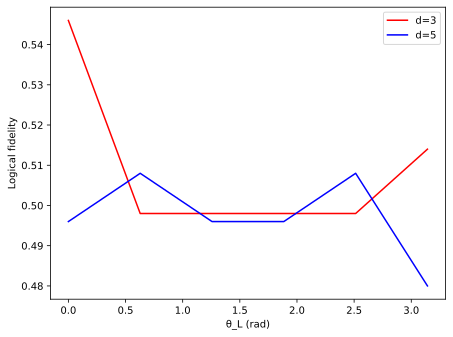

In [321]:
shots = 500
angles_pi = np.linspace(0, np.pi, 6)   # logical angle in units of π
for d in [3,5]:    
    print(f"DOING {d}...")
    log_errors = []

    for angle in angles_pi:
        print(f"Angle {angle}.")
        star_circ = squin_to_circuit(make_star_rotation(d=d, logical_angle=angle, MUTE_DETECTORS=False))
        # star_circ = squin_to_circuit(noisy_star_squin)
        sampler = star_circ.compile_detector_sampler(seed=42)
        dets, obs = sampler.sample(shots, separate_observables=True)
        clean = (dets == 0).all(axis=1)
        print(f"  Clean shots: {clean.sum()}/{len(clean)} ({100*clean.mean():.1f}%)")
        err = obs[clean, 0].mean()
        log_errors.append(err)

    plt.plot(angles_pi, log_errors)
    line = plt.gca().lines[-1]
    line.set_color("red" if d == 3 else "blue")
    line.set_label(f"d={d}")
    plt.legend()

plt.xlabel("θ_L (rad)")
plt.ylabel("Logical fidelity")
plt.tight_layout()
plt.show()

DIST  3
  angle  0.01 ...
  angle  0.09999999999999999 ...
  angle  0.19 ...
  angle  0.28 ...
  angle  0.37 ...
  angle  0.45999999999999996 ...
  angle  0.55 ...
  angle  0.64 ...
  angle  0.73 ...
  angle  0.82 ...
  angle  0.9099999999999999 ...
  angle  1.0 ...
DIST  5
  angle  0.01 ...
  angle  0.09999999999999999 ...
  angle  0.19 ...
  angle  0.28 ...
  angle  0.37 ...
  angle  0.45999999999999996 ...
  angle  0.55 ...
  angle  0.64 ...
  angle  0.73 ...
  angle  0.82 ...
  angle  0.9099999999999999 ...
  angle  1.0 ...


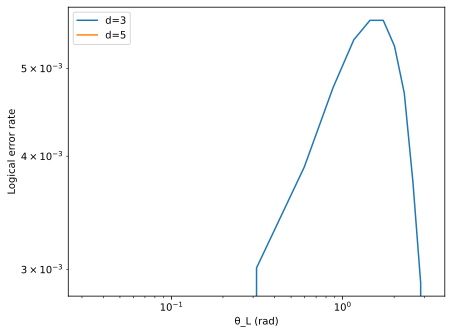

In [ ]:
import re
from tsim.utils.program_text import shorthand_to_stim


def load_star_circuit(d: int, logical_angle_in_pi: float) -> tsim.Circuit:
    """Load star_d={d}.stim and patch both R_Z angles for the given logical rotation.

    The file contains exactly two R_Z lines:
      1st: d targets  → transversal physical rotation  → replace angle with phys_angle
      2nd: 1 target   → logical unrotation             → replace angle with -logical_angle_in_pi
    Both use tsim shorthand R_Z(angle_in_pi_units) which shorthand_to_stim converts to stim I[...].
    """
    with open(f"assets/star_circuits/star_d={d}.stim") as f:
        text = f.read()

    phys_angle = logical_to_physical_angle(logical_angle_in_pi, d)
    rz_count = 0

    def replace_rz(m):
        nonlocal rz_count
        rz_count += 1
        targets = m.group(1)  # rest of line after R_Z(...)
        angle = phys_angle if rz_count == 1 else -logical_angle_in_pi
        return f"R_Z({angle}){targets}"

    patched = re.sub(r"R_Z\([^)]+\)([^\n]*)", replace_rz, text)
    return tsim.Circuit.from_stim_program(stim.Circuit(shorthand_to_stim(patched)))


# --- fidelity sweep ---
shots = 5000
angles_pi = np.linspace(0.01, 1, 12)  # logical angle in units of π: 0.01π to π/2

plt.figure()
for d in [3, 5]:
    print("DIST ", d)
    errs = []
    for a in angles_pi:
        print("  angle ", a, "...")
        circ = load_star_circuit(d=d, logical_angle_in_pi=a)
        sampler = circ.compile_detector_sampler(seed=42)
        dets, obs = sampler.sample(shots, separate_observables=True)
        clean = (dets == 0).all(axis=1)
        errs.append(obs[clean, 0].mean())
    plt.loglog(angles_pi * np.pi, errs, label=f"d={d}")

plt.xlabel("θ_L (rad)")
plt.ylabel("Logical error rate")
plt.legend()
plt.tight_layout()
plt.show()


## Team STAR Part 3 — Teleport a non-Clifford rotation into a logical qubit
Now assume a noiseless setting but where non-Clifford gates cannot be applied directly to the main logical qubit. 
Construct a protocol that uses an ancillary logical qubit to teleport a small-angle rotation into the main qubit while assuming the STAR transversal architecture.
Important: you will need to use postselection to filter results because Tsim (unlike PyQrack) does not support feed-forwarded operations.

![rus.png](./assets/rus.png)

Figure taken from *"Partially Fault-Tolerant Quantum Computing Architecture with Error-Corrected Clifford Gates and Space-Time Efficient Analog Rotations"* by *Akahoshi et al.*

**Goal:** Show how STAR enables indirect implementation of small-angle non-Clifford logical rotations, and analyze the costs of doing so. 


In [ ]:
# part 3